# MacSentinel 03 · Streaming Anomaly Detection

## tl;dr

A transparent robust-z detector produces a review queue without requiring attack labels. Thresholds are selected against analyst capacity, then compared with a supervised logistic benchmark using a host-separated holdout.

## Goal

Detect unusual macOS sessions while making alert volume, false positives, and threshold trade-offs visible.

**Safety and scope:** all events are deterministic synthetic fixtures. Reserved `.example` domains and inert filenames are used; this project does not execute payloads, collect private data, or bypass platform controls.


## Setup

Load the shared synthetic macOS telemetry fixture and dependency-light visualization helpers. The data source and seed are explicit so every result can be reproduced offline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from macsentinel.core import *
from macsentinel.visuals import *

SEED = 42
DATA_PATH = Path("macsentinel/data/synthetic_macos_events.csv")
events = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
FIGURES = []
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"Loaded {len(events):,} synthetic events across {events.session_id.nunique():,} sessions and {events.host_id.nunique()} hosts.")


Loaded 2,520 synthetic events across 420 sessions and 30 hosts.


## Steps

### 1. Aggregate sessions and create a host-separated split


In [2]:
sessions = aggregate_sessions(events)
train_index, test_index = group_train_test_split(sessions, test_fraction=0.30)
features = sessions[FEATURE_COLUMNS].to_numpy()
labels = sessions.label.to_numpy()
print(pd.Series({"train_sessions": len(train_index), "test_sessions": len(test_index), "test_hosts": sessions.iloc[test_index].host_id.nunique(), "test_attack_rate": labels[test_index].mean()}).to_string())


train_sessions      297.000000
test_sessions       123.000000
test_hosts            9.000000
test_attack_rate      0.178862


### 2. Score the test stream with a transparent anomaly baseline


In [3]:
anomaly_scores = robust_anomaly_score(features)
test_scores = anomaly_scores[test_index]
capacity_threshold = float(np.quantile(test_scores, 0.86))
anomaly_metrics = evaluate_scores(labels[test_index], test_scores, capacity_threshold)
print(pd.Series(anomaly_metrics).round(4).to_string())


precision             0.5000
recall                0.4091
f1                    0.4500
accuracy              0.8211
tp                    9.0000
fp                    9.0000
tn                   92.0000
fn                   13.0000
average_precision     0.5117
threshold             0.4139
alert_rate            0.1463


### 3. Compare a supervised detection model


In [4]:
logistic_model = fit_logistic(features[train_index], labels[train_index], FEATURE_COLUMNS)
logistic_scores = predict_logistic(logistic_model, features[test_index])
logistic_metrics = evaluate_scores(labels[test_index], logistic_scores, 0.50)
comparison = pd.DataFrame([anomaly_metrics, logistic_metrics], index=["robust anomaly", "logistic"])
print(comparison[["precision", "recall", "f1", "average_precision", "alert_rate"]].round(3).to_string())


                precision  recall     f1  average_precision  alert_rate
robust anomaly        0.5   0.409  0.450              0.512       0.146
logistic              0.7   0.955  0.808              0.969       0.244


## Visual Insights & ML Extension

### 4. Visualize score separation


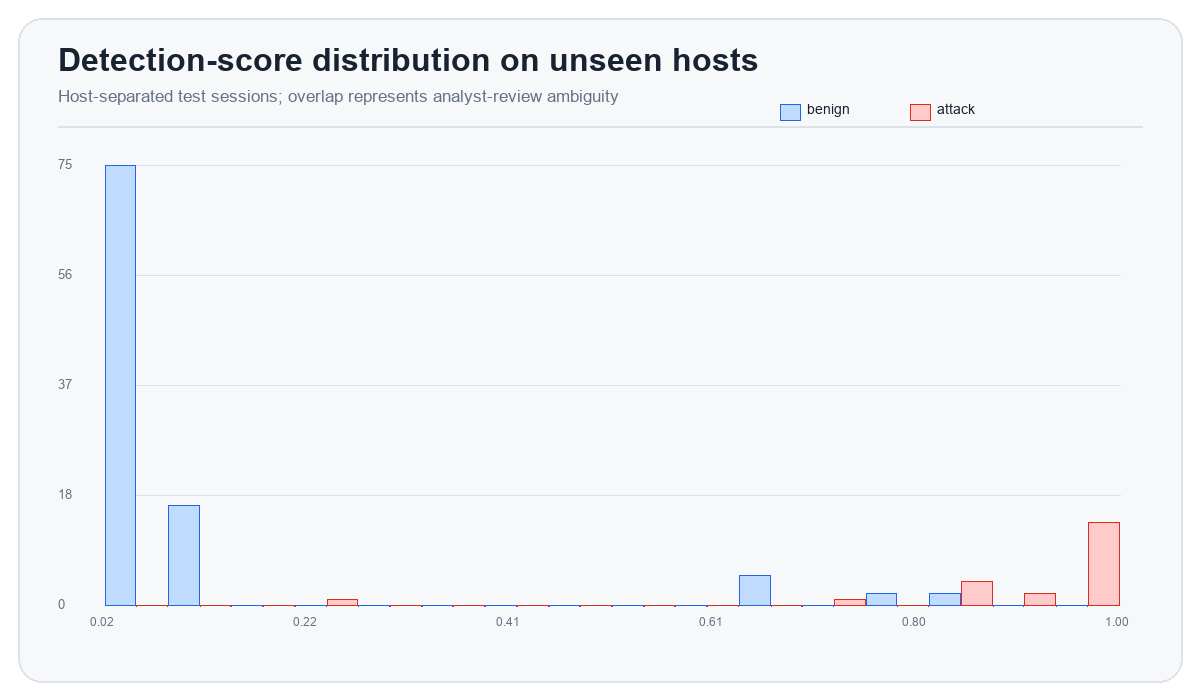

In [5]:
test_labels = labels[test_index]
figure = histogram(
    {"benign": logistic_scores[test_labels == 0], "attack": logistic_scores[test_labels == 1]},
    "Detection-score distribution on unseen hosts",
    "Host-separated test sessions; overlap represents analyst-review ambiguity",
)
FIGURES.append(figure)
figure


### 5. Tune precision, recall, and alert volume


Selected analyst-capacity operating point:
 threshold     0.817
precision     0.909
recall        0.909
f1            0.909
alert_rate    0.179


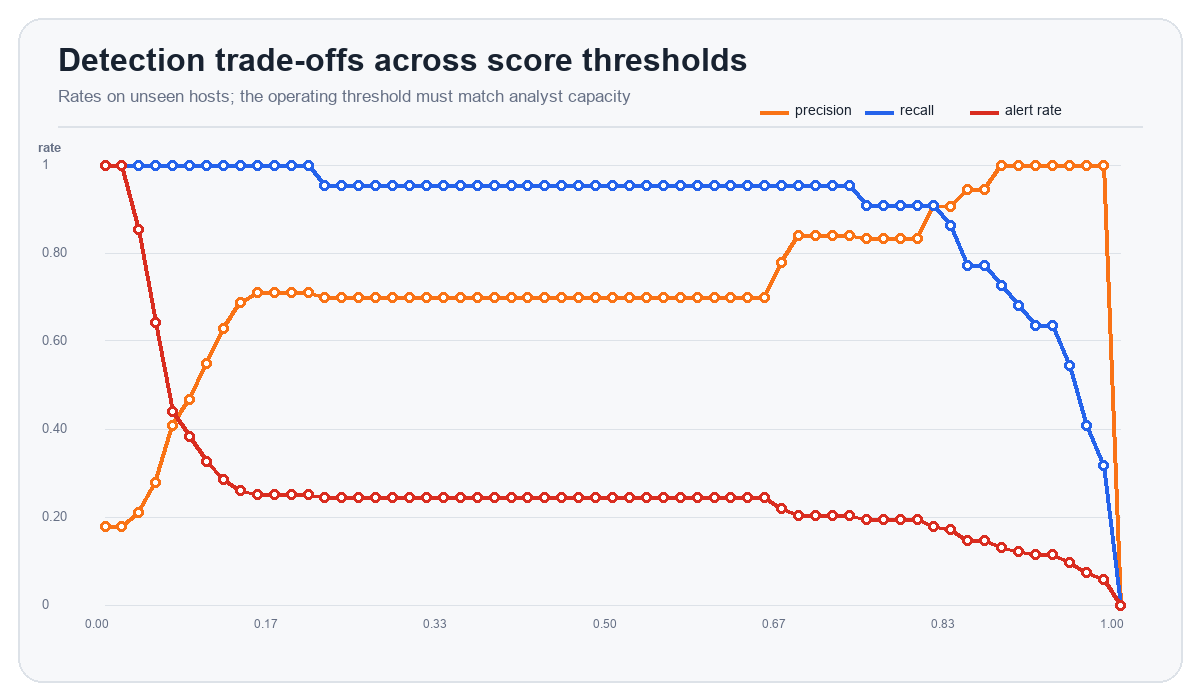

In [6]:
curve = precision_recall_curve(test_labels, logistic_scores)
feasible = curve[curve.alert_rate.le(0.20)].sort_values(["recall", "precision"], ascending=False)
selected = feasible.iloc[0]
print("Selected analyst-capacity operating point:\n", selected[["threshold", "precision", "recall", "f1", "alert_rate"]].round(3).to_string())

figure = line_chart(
    [f"{value:.2f}" for value in curve.threshold],
    {"precision": curve.precision, "recall": curve.recall, "alert rate": curve.alert_rate},
    "Detection trade-offs across score thresholds",
    "Rates on unseen hosts; the operating threshold must match analyst capacity",
    "rate",
)
FIGURES.append(figure)
figure


## Checks


In [7]:
train_hosts = set(sessions.iloc[train_index].host_id)
test_hosts = set(sessions.iloc[test_index].host_id)
assert train_hosts.isdisjoint(test_hosts)
assert np.all((logistic_scores >= 0) & (logistic_scores <= 1))
assert 0 < selected.alert_rate <= 0.20
print("PASS: entity leakage is blocked, scores are calibrated to [0, 1], and the queue respects capacity.")


PASS: entity leakage is blocked, scores are calibrated to [0, 1], and the queue respects capacity.


## Next Steps

- Calibrate thresholds from real analyst dispositions instead of synthetic labels.
- Monitor alert rate and precision by macOS version and host role.
- Use graph and sequence models only when they beat this transparent baseline under equal review budgets.
